<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2.3   2.3.1 - 2.3.3

* Used Gemini as a study aid and coding partner to clarify probability definitions, debug python code, and format LaTex formulas.
* I only finished up to 2.3.1 before the due date, but thought I'd finish the rest for practice.
__________________________________________________________________

1. Joint Probability Distributuions (2.3.1)
2. Correlation and Dependence (2.3.2)
3. Random Samples(2.3.3)

__________________________________________________________________

# Joint Probability Distributions (2.3.1)

Key Concept (Explained and given python example):

* For tracking two discrete variables, say $X$ and $Y$, Joint Probability Mass Function (PMF) $p(x, y) = P(X = x, Y = y)$ gives the probablity of both values occurring simultaneously.
* For continuous variables, we can define with a joint PDF $f(x, y) \ge 0$, where $P((X,Y) \in A)$ represents the 3D volume under $f(x, y)$ above region $A$. Integrating out one variable yields the marginal PDF ($f_X(x) = \int_{-\infty}^{\infty} f(x, y) \, dy$).
* For independence, two variables are dependent iff their joint distribution factors into the product of their marginal distributions ($p(x, y) = p_X(x) \cdot p_Y(y)$ or $f(x, y) = f_X(x) \cdot f_Y(y)$ for all $x, y$).



SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS

--- Joint PMF Table with Marginals ---
            Y=1 (Low)  Y=2 (Med)  Y=3 (High)  p_X(x)
X=1 (Low)        0.10       0.05        0.02    0.17
X=2 (Med)        0.08       0.20        0.10    0.38
X=3 (High)       0.02       0.15        0.28    0.45
p_Y(y)           0.20       0.40        0.40    1.00

Total Discrete Probability Sum: 1.0000


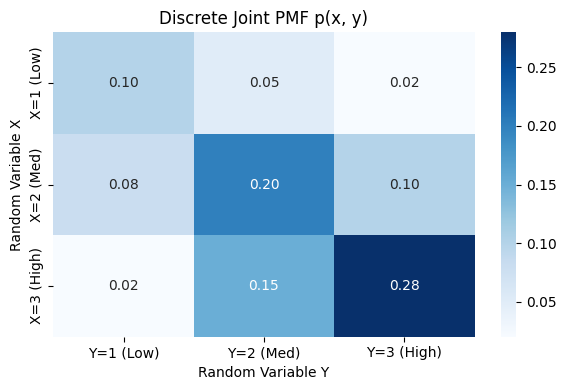


SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES

Total Volume ∫∫ f(x,y) dx dy = 1.000000
P(0.5 <= X <= 1, 0 <= Y <= 0.5) = 0.250000


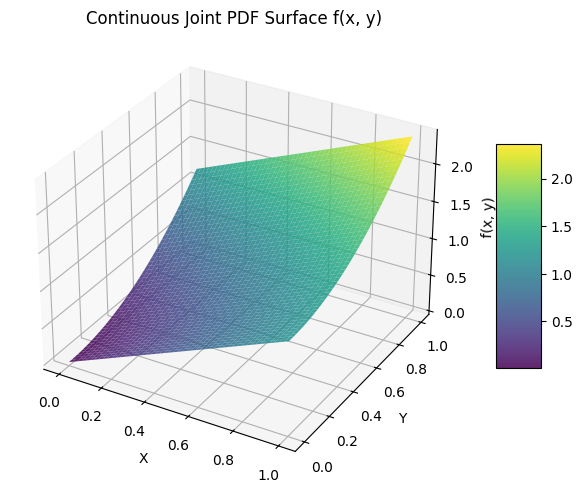


SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES

P(X1 >= 1400) = 0.2801
P(X2 >= 1400) = 0.3406
P(Both >= 1400) [Product Rule] = 0.0954
P(Both >= 1400) [Numerical Integration] = 0.0954


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# ==============================================================================
# SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS
# ==============================================================================
print("=" * 60)
print("SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS")
print("=" * 60)

# 1. Define Joint PMF Matrix (X = Study Hours, Y = Exam Score Tier)
pmf_data = np.array([
    [0.10, 0.05, 0.02],
    [0.08, 0.20, 0.10],
    [0.02, 0.15, 0.28]
])

# 2. Build Pandas DataFrame
df_pmf = pd.DataFrame(
    pmf_data,
    index=['X=1 (Low)', 'X=2 (Med)', 'X=3 (High)'],
    columns=['Y=1 (Low)', 'Y=2 (Med)', 'Y=3 (High)']
)

# 3. Compute Marginals
marginal_X = df_pmf.sum(axis=1)  # Row sums -> p_X(x)
marginal_Y = df_pmf.sum(axis=0)  # Column sums -> p_Y(y)

# Format table for visual output
df_display = df_pmf.copy()
df_display['p_X(x)'] = marginal_X
df_display.loc['p_Y(y)'] = list(marginal_Y) + [df_pmf.values.sum()]

print("\n--- Joint PMF Table with Marginals ---")
print(df_display.round(2))

total_discrete_prob = np.sum(pmf_data)
print(f"\nTotal Discrete Probability Sum: {total_discrete_prob:.4f}")

# Heatmap Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(df_pmf, annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("Discrete Joint PMF p(x, y)")
plt.xlabel("Random Variable Y")
plt.ylabel("Random Variable X")
plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES & 3D SURFACE
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES")
print("=" * 60)

# Define continuous joint PDF f(x, y) = 6/5 * (x + y^2) on [0,1] x [0,1]
def joint_pdf(y, x):
    if 0 <= x <= 1 and 0 <= y <= 1:
        return (6/5) * (x + y**2)
    return 0.0

# Verify total probability over unit square = 1
total_cont_prob, _ = integrate.dblquad(joint_pdf, 0, 1, lambda x: 0, lambda x: 1)
print(f"\nTotal Volume ∫∫ f(x,y) dx dy = {total_cont_prob:.6f}")

# Compute probability over region A: [0.5, 1.0] x [0.0, 0.5]
prob_region_A, _ = integrate.dblquad(joint_pdf, 0.5, 1.0, lambda x: 0, lambda x: 0.5)
print(f"P(0.5 <= X <= 1, 0 <= Y <= 0.5) = {prob_region_A:.6f}")

# 3D Surface Plot
x_vals = np.linspace(0, 1, 50)
y_vals = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (6/5) * (X + Y**2)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Continuous Joint PDF Surface f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES")
print("=" * 60)

# Exponential distribution parameters
lambda1 = 1 / 1100  # Mean lifetime 1100 hours
lambda2 = 1 / 1300  # Mean lifetime 1300 hours
t = 1400

# Analytical individual probabilities
p_x1_ge_1400 = np.exp(-lambda1 * t)
p_x2_ge_1400 = np.exp(-lambda2 * t)

# Joint probability using independence rule
p_both_ge_1400 = p_x1_ge_1400 * p_x2_ge_1400

print(f"\nP(X1 >= 1400) = {p_x1_ge_1400:.4f}")
print(f"P(X2 >= 1400) = {p_x2_ge_1400:.4f}")
print(f"P(Both >= 1400) [Product Rule] = {p_both_ge_1400:.4f}")

# Verification via double numerical integration (using 20,000 hrs instead of np.inf to prevent warnings)
def joint_exp_pdf(x2, x1):
    return (lambda1 * np.exp(-lambda1 * x1)) * (lambda2 * np.exp(-lambda2 * x2))

upper_limit = 20000  # Realistic upper bound for numerical integration

p_integrated, _ = integrate.dblquad(
    joint_exp_pdf,
    1400, upper_limit,
    lambda x1: 1400, lambda x1: upper_limit
)
print(f"P(Both >= 1400) [Numerical Integration] = {p_integrated:.4f}")

* We illustrate all concepts. For discrete, we use a grid where each cell shows a probability. It is correct as each adds up to 1.
* The concept is similar for continuous except now we check if the entire 3D volume adds up to 1, which it does.
* For the Independent variables, we model separate components, like equipment with different lifetimes. We calculate the probability both keep working past 1400 hours. It's verified with different methods to ensure correctness, and both yield the same value.

# Correlation and Dependence 2.3.2
Key Concept (Explained and given python example):

* For jointly distributed random variables say $X$ and $Y$ we can measure how they vary together using covariance and correlation. (Different formulas for discrete and continuous as per usual)


$$\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)] = E[XY] - \mu_X \mu_Y$$

Discrete: $\sum_x \sum_y (x - \mu_X)(y - \mu_Y) p(x, y)$



Continuous: $\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} (x - \mu_X)(y - \mu_Y) f(x, y) \, dx \, dy$


Self-Covariance: $\text{Cov}(X, X) = V(X)$

* Population Correlation standardizes covariance by standard deviations which measure linear relationship strength.
$$\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$$-1 \le \rho \le 1$

$\rho = 1$ or $-1$ if $Y = aX + b$ ($a \neq 0$)

Independence $\implies \rho = 0$ (Note: $\rho = 0 \nRightarrow$ independence)

* Sample Pearson Correlation measures linear correlation for sample pairs. $\{(x_i, y_i)\}_{i=1}^n$.$$r_{xy} = \frac{s_{xy}}{s_x s_y} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$Sample Covariance: $s_{xy} = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$

$r_{xy} = 1$ or $-1$ if $y = ax + b$ ($a > 0$ or $a < 0$

1. DISCRETE RANDOM VARIABLES: COVARIANCE & CORRELATION
E[X] = 2.28, E[Y] = 22.00
Var(X) = 0.5416, Var(Y) = 56.0000
Covariance Cov(X, Y) = 2.8400
Correlation Coefficient (rho) = 0.5157

2. CONTINUOUS RANDOM VARIABLES: DOUBLE INTEGRATION
E[X] = 0.5833, E[Y] = 0.5833
Covariance Cov(X, Y) = -0.006944
Correlation Coefficient (rho) = -0.0909  (Exact theoretical: -1/11 = -0.0909)

3. SAMPLE CORRELATION PROPERTIES & NONLINEAR DEPENDENCE
Case A (Linear y = 2x + 5)   -> r_xy = 1.0000 (Property: r = +1)
Case B (Linear y = -3x + 10)  -> r_xy = -1.0000 (Property: r = -1)
Case C (Nonlinear y = x^2)    -> r_xy = 0.0015 (Proves r = 0 != Independence)


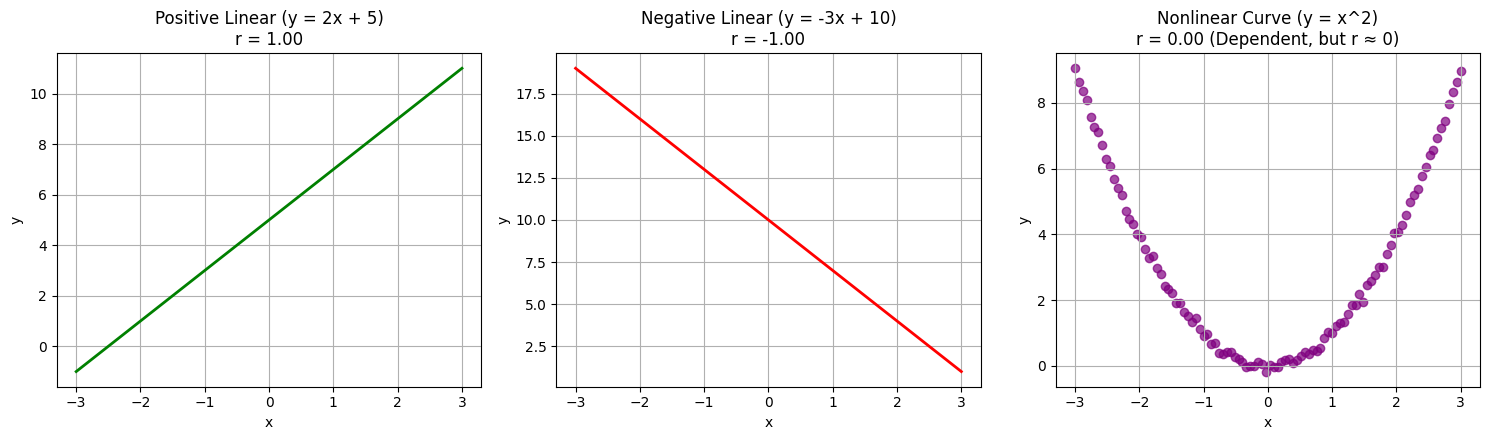

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# ==============================================================================
# 1. DISCRETE RANDOM VARIABLES: COVARIANCE & CORRELATION
# ==============================================================================
print("=" * 65)
print("1. DISCRETE RANDOM VARIABLES: COVARIANCE & CORRELATION")
print("=" * 65)

# Values for X (Study Hours) and Y (Exam Score)
x_vals = np.array([1, 2, 3])
y_vals = np.array([10, 20, 30])

# Joint PMF Matrix p(x, y)
pmf = np.array([
    [0.10, 0.05, 0.02],
    [0.08, 0.20, 0.10],
    [0.02, 0.15, 0.28]
])

# Compute Means E[X] and E[Y]
mu_x = np.sum(x_vals[:, None] * pmf)
mu_y = np.sum(y_vals[None, :] * pmf)

# Compute Variances V(X) and V(Y)
var_x = np.sum(((x_vals[:, None] - mu_x) ** 2) * pmf)
var_y = np.sum(((y_vals[None, :] - mu_y) ** 2) * pmf)
sigma_x, sigma_y = np.sqrt(var_x), np.sqrt(var_y)

# Compute Covariance and Correlation
cov_xy_discrete = np.sum((x_vals[:, None] - mu_x) * (y_vals[None, :] - mu_y) * pmf)
rho_discrete = cov_xy_discrete / (sigma_x * sigma_y)

print(f"E[X] = {mu_x:.2f}, E[Y] = {mu_y:.2f}")
print(f"Var(X) = {var_x:.4f}, Var(Y) = {var_y:.4f}")
print(f"Covariance Cov(X, Y) = {cov_xy_discrete:.4f}")
print(f"Correlation Coefficient (rho) = {rho_discrete:.4f}")

# ==============================================================================
# 2. CONTINUOUS RANDOM VARIABLES: DOUBLE INTEGRATION
# ==============================================================================
print("\n" + "=" * 65)
print("2. CONTINUOUS RANDOM VARIABLES: DOUBLE INTEGRATION")
print("=" * 65)

# Define continuous Joint PDF f(x, y) = x + y on [0,1] x [0,1]
def f(y, x): return x + y if (0 <= x <= 1 and 0 <= y <= 1) else 0.0

# Expected Values E[X], E[Y], E[X^2], E[Y^2], E[XY]
E_X, _  = integrate.dblquad(lambda y, x: x * f(y, x), 0, 1, lambda x: 0, lambda x: 1)
E_Y, _  = integrate.dblquad(lambda y, x: y * f(y, x), 0, 1, lambda x: 0, lambda x: 1)
E_X2, _ = integrate.dblquad(lambda y, x: (x**2) * f(y, x), 0, 1, lambda x: 0, lambda x: 1)
E_Y2, _ = integrate.dblquad(lambda y, x: (y**2) * f(y, x), 0, 1, lambda x: 0, lambda x: 1)
E_XY, _ = integrate.dblquad(lambda y, x: (x * y) * f(y, x), 0, 1, lambda x: 0, lambda x: 1)

# Covariance & Correlation
Var_X_cont = E_X2 - E_X**2
Var_Y_cont = E_Y2 - E_Y**2
Cov_XY_cont = E_XY - (E_X * E_Y)
rho_cont = Cov_XY_cont / np.sqrt(Var_X_cont * Var_Y_cont)

print(f"E[X] = {E_X:.4f}, E[Y] = {E_Y:.4f}")
print(f"Covariance Cov(X, Y) = {Cov_XY_cont:.6f}")
print(f"Correlation Coefficient (rho) = {rho_cont:.4f}  (Exact theoretical: -1/11 = {-1/11:.4f})")

# ==============================================================================
# 3. SAMPLE CORRELATION (PEARSON r_xy) & NONLINEARITY DEMO
# ==============================================================================
print("\n" + "=" * 65)
print("3. SAMPLE CORRELATION PROPERTIES & NONLINEAR DEPENDENCE")
print("=" * 65)

np.random.seed(42)
n = 100
x_sample = np.linspace(-3, 3, n)

# Case A: Positive Linear Transformation (y = 2x + 5)
y_pos_linear = 2 * x_sample + 5

# Case B: Negative Linear Transformation (y = -3x + 10)
y_neg_linear = -3 * x_sample + 10

# Case C: Quadratic/Nonlinear Relationship (y = x^2 + noise)
y_quadratic = x_sample**2 + np.random.normal(0, 0.1, n)

# Manual Pearson Formula function
def compute_sample_r(x, y):
    x_bar, y_bar = np.mean(x), np.mean(y)
    numerator = np.sum((x - x_bar) * (y - y_bar))
    denominator = np.sqrt(np.sum((x - x_bar)**2) * np.sum((y - y_bar)**2))
    return numerator / denominator

r_a = compute_sample_r(x_sample, y_pos_linear)
r_b = compute_sample_r(x_sample, y_neg_linear)
r_c = compute_sample_r(x_sample, y_quadratic)

print(f"Case A (Linear y = 2x + 5)   -> r_xy = {r_a:.4f} (Property: r = +1)")
print(f"Case B (Linear y = -3x + 10)  -> r_xy = {r_b:.4f} (Property: r = -1)")
print(f"Case C (Nonlinear y = x^2)    -> r_xy = {r_c:.4f} (Proves r = 0 != Independence)")

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(x_sample, y_pos_linear, color='green', linewidth=2)
axes[0].set_title(f"Positive Linear (y = 2x + 5)\nr = {r_a:.2f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)

axes[1].plot(x_sample, y_neg_linear, color='red', linewidth=2)
axes[1].set_title(f"Negative Linear (y = -3x + 10)\nr = {r_b:.2f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True)

axes[2].scatter(x_sample, y_quadratic, color='purple', alpha=0.7)
axes[2].set_title(f"Nonlinear Curve (y = x^2)\nr = {r_c:.2f} (Dependent, but r ≈ 0)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].grid(True)

plt.tight_layout()
plt.show()

* Again we verify each concept in python with multiple examples. First using discrete variables by calculating covariance and and correlation for a discrete probability table. Since our output falls between -1 and 1, we can be mostly confident it's correct.
* Then for continuous variables, we calculate $E[X]$, $E[Y]$, $E[XY]$, and variance for $f(x, y) = x + y$, then calculates the theoretical correlation coefficient. It's verified since the numerical integration matches the exact theoretical fraction.
* Then for sample correlations, we verify with linear transformations and n a nonlinear proof.

# Random Samples 2.3.3

Key Concept (Explained and given python example):

* Simple Random Sample (i.i.d.): $X_1, X_2, \dots, X_n$ are independent and identically distributed (i.i.d.) random variables, each drawn from the same population with mean $\mu$ and variance $\sigma^2$.
* Sample Mean ($\bar{X}$) & Sample Total ($T_o$):$$\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i, \quad T_o = \sum_{i=1}^{n} X_i$$
* Expected Values & Variances (Proposition 2.3.14):

Mean: $E(\bar{X}) = \mu$ $\quad$ and $\quad$ $E(T_o) = n\mu$

Variance: $V(\bar{X}) = \frac{\sigma^2}{n}$ $\quad$ and $\quad$ $V(T_o) = n\sigma^2$

Standard Deviation: $\sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}}$ $\quad$ and $\quad$ $\sigma_{T_o} = \sqrt{n}\sigma$

* Central Limit Theorem (CLT - Theorem 2.3.15): As sample size $n$ becomes sufficiently large ($n \ge 30$), the sampling distribution of $\bar{X}$ approaches a normal distribution regardless of the underlying population shape:$$\bar{X} \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right), \quad T_o \approx \mathcal{N}\left(n\mu, n\sigma^2\right)$$

1. RANDOM SAMPLE PROPERTIES: E(X_bar), V(X_bar), E(T_o), V(T_o)
Population Parameters -> Mean (mu): 2.00, Var (sigma^2): 4.00
-----------------------------------------------------------------
Sample Mean E(X_bar)  | Theoretical: 2.0000  | Empirical: 2.0023
Sample Mean V(X_bar)  | Theoretical: 0.1333  | Empirical: 0.1358
Sample Total E(T_o)   | Theoretical: 60.0000 | Empirical: 60.0679
Sample Total V(T_o)   | Theoretical: 120.0000| Empirical: 122.1956

2. CENTRAL LIMIT THEOREM (CLT) CONVERGENCE


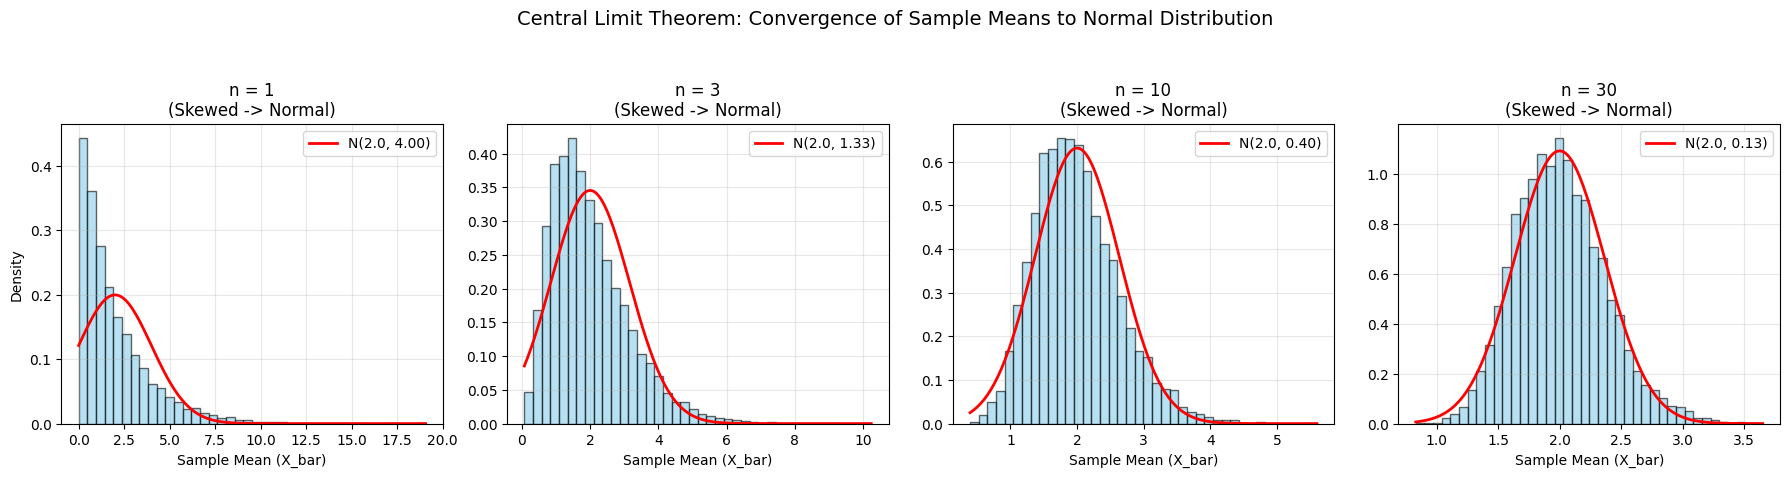

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Fix random seed for reproducibility
np.random.seed(42)

# ==============================================================================
# 1. RANDOM SAMPLE PROPERTIES (PROPOSITION 2.3.14)
# ==============================================================================
print("=" * 65)
print("1. RANDOM SAMPLE PROPERTIES: E(X_bar), V(X_bar), E(T_o), V(T_o)")
print("=" * 65)

# Highly skewed underlying population: Exponential distribution (lambda = 0.5)
# Theoretical population parameters: mu = 1/lambda = 2.0, sigma^2 = 1/lambda^2 = 4.0
mu_pop = 2.0
sigma_pop = 2.0
var_pop = sigma_pop ** 2

n = 30           # Sample size
num_samples = 10000  # Number of repeated samples

# Draw 10,000 samples of size 30 from exponential population
samples = np.random.exponential(scale=mu_pop, size=(num_samples, n))

# Compute empirical sample means (X_bar) and sample totals (T_o) for each sample
x_bars = np.mean(samples, axis=1)
t_totals = np.sum(samples, axis=1)

# Theoretical expectations vs Empirical estimates
print(f"Population Parameters -> Mean (mu): {mu_pop:.2f}, Var (sigma^2): {var_pop:.2f}")
print("-" * 65)
print(f"Sample Mean E(X_bar)  | Theoretical: {mu_pop:.4f}  | Empirical: {np.mean(x_bars):.4f}")
print(f"Sample Mean V(X_bar)  | Theoretical: {var_pop / n:.4f}  | Empirical: {np.var(x_bars, ddof=1):.4f}")
print(f"Sample Total E(T_o)   | Theoretical: {n * mu_pop:.4f} | Empirical: {np.mean(t_totals):.4f}")
print(f"Sample Total V(T_o)   | Theoretical: {n * var_pop:.4f}| Empirical: {np.var(t_totals, ddof=1):.4f}")

# ==============================================================================
# 2. CENTRAL LIMIT THEOREM DEMONSTRATION (THEOREM 2.3.15)
# ==============================================================================
print("\n" + "=" * 65)
print("2. CENTRAL LIMIT THEOREM (CLT) CONVERGENCE")
print("=" * 65)

sample_sizes = [1, 3, 10, 30]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for idx, size in enumerate(sample_sizes):
    # Generate sample means for varying sample sizes
    means = np.mean(np.random.exponential(scale=mu_pop, size=(num_samples, size)), axis=1)

    # Plot histogram of sample means
    ax = axes[idx]
    ax.hist(means, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='black')

    # Overlay theoretical Normal distribution predicted by CLT: N(mu, sigma^2 / n)
    se = sigma_pop / np.sqrt(size)  # Standard error sigma / sqrt(n)
    x_grid = np.linspace(min(means), max(means), 200)
    normal_pdf = stats.norm.pdf(x_grid, loc=mu_pop, scale=se)
    ax.plot(x_grid, normal_pdf, 'r-', linewidth=2, label=f'N({mu_pop}, {se**2:.2f})')

    ax.set_title(f"n = {size}\n(Skewed -> Normal)")
    ax.set_xlabel("Sample Mean (X_bar)")
    if idx == 0:
        ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Central Limit Theorem: Convergence of Sample Means to Normal Distribution", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

* For 10,000 independent random samples of size n = 30 from a skewed exponential population, we compute the sample mean and sample total for each run.
* We verify that $E(\bar{X})$ matches, $V(\bar{X})$ matches, $E(T_o)$ matches, and $V(T_o)$ matches
* For the central limit theory we plot the distribution of sample means across increasing sample sizes ($n = 1, 3, 10, 30$) and overlays the theoretical normal curve predicted by the CLT. We see it matches what's expected.


# Checklist


*   Read, checked, and personalized each example. Also extended at least one example. They run without errors.
*   Covered key concepts from the textbook and illustrated them in python.
*   Explanations written in my own words accompany each example.
*   Saved directly from collab to github.
*   Carefully formatted, code is explained in comments, and it follows the given order from the textbook and in the canvas assignments.